# 04 · Linear regression (MOS)

**Input:** `data/processed/model_samples_2024-03-14_to_2026-09-16.csv.gz` (from `03`).
**Output:** `reports/forecast_2026-09-17_to_2026-09-30_linear_regression.csv`, the hourly forecast for 12am Sep 17 – 11pm Sep 30, 2026.

**Model.** One scikit-learn `LinearRegression` per forecast day (14 models). Each predicts how much warmer or colder than the historical average an hour will be, from the ECMWF forecast, ECMWF's recent errors and biases, the station's current anomaly and the hour of day. Forecast = historical average + predicted difference. Recent runs get more weight (half-life 180 days) because ECMWF's bias at RDU changes over time (`02`, Section 5.4).

## 1. Settings

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
SAMPLES_FILE = PROJECT_ROOT / "data" / "processed" / "model_samples_2024-03-14_to_2026-09-16.csv.gz"
FORECAST_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_linear_regression.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

NY = "America/New_York"
CUTOFF = pd.Timestamp("2026-09-17", tz=NY)
FINAL_RUN_DAY = pd.Timestamp("2026-09-16")
FEATURES = ["nwp_lagged_anomaly", "nwp_anomaly", "nwp_recent_error", "nwp_bias_14d", "nwp_bias_30d", "nwp_bias_60d",
            "anom_now", "anom_24h", "hour_sin1", "hour_cos1", "hour_sin2", "hour_cos2"]
HALF_LIFE_DAYS = 180  # weight of a training run halves every 180 days before the newest run


def save_fig(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")


samples = pd.read_csv(SAMPLES_FILE, parse_dates=["run_day", "target_utc"])
print(f"Loaded {SAMPLES_FILE.relative_to(PROJECT_ROOT)}: {len(samples):,} rows, "
      f"run days {samples['run_day'].min():%Y-%m-%d} .. {samples['run_day'].max():%Y-%m-%d}")

Loaded data/processed/model_samples_2024-03-14_to_2026-09-16.csv.gz: 308,112 rows, run days 2024-03-14 .. 2026-09-16


## 2. Model and evaluation helpers

- `fit_lr` trains the 14 regressions; `predict_lr` applies them.
- `evaluate` trains on rows whose **target time is before** the evaluation period, then scores all methods on the same hours: those where every method has a forecast (for example, one ECMWF run in the archive only has 72 hours of temperature).
- Methods compared: two heuristics (persistence = repeat the last observed day; historical average), the raw ECMWF forecast, the ECMWF lagged mean (average of the last three runs), and the linear regression.

In [3]:
def fit_lr(train):
    """One LinearRegression per forecast day: (temperature - hist_avg) ~ FEATURES, recent runs weighted more."""
    newest = train["run_day"].max()
    models = {}
    for day in range(1, 15):
        rows = train[train["lead_day"].eq(day)].dropna(subset=["temperature", "hist_avg", *FEATURES])
        weight = 0.5 ** ((newest - rows["run_day"]).dt.days / HALF_LIFE_DAYS)
        models[day] = LinearRegression().fit(rows[FEATURES], rows["temperature"] - rows["hist_avg"], sample_weight=weight)
    return models


def predict_lr(models, rows):
    prediction = np.full(len(rows), np.nan)
    for day, model in models.items():
        ok = (rows["lead_day"].eq(day) & rows[FEATURES].notna().all(axis=1)).to_numpy()
        prediction[ok] = rows["hist_avg"].to_numpy()[ok] + model.predict(rows.loc[ok, FEATURES])
    return prediction


def evaluate(first_run_day, last_run_day, train_before):
    """Train on rows whose target is before `train_before`, forecast the run days in [first, last]; return errors."""
    start_utc = pd.Timestamp(train_before, tz=NY).tz_convert("UTC")
    train = samples[(samples["target_utc"] < start_utc) & samples["temperature"].notna()]
    test = samples[samples["run_day"].between(first_run_day, last_run_day) & samples["temperature"].notna()]
    assert train["target_utc"].max() < start_utc <= test["target_utc"].min()  # no training target inside the test period
    forecasts = pd.DataFrame({
        "Persistence": test["persistence"],
        "Historical average": test["hist_avg"],
        "ECMWF raw": test["ecmwf_12z"],
        "ECMWF lagged mean": test["ecmwf_lagged_mean"],
        "Linear regression": predict_lr(fit_lr(train), test),
    }, index=test.index)
    keep = forecasts.notna().all(axis=1)  # score only hours where every method has a forecast
    errors = forecasts[keep].rsub(test.loc[keep, "temperature"], axis=0)  # observed - forecast
    return errors.assign(lead_day=test.loc[keep, "lead_day"])


mae = lambda e: e.abs().mean()
rmse = lambda e: np.sqrt((e ** 2).mean())
METHODS = ["Persistence", "Historical average", "ECMWF raw", "ECMWF lagged mean", "Linear regression"]

## 3. Validation: two season-matched folds

| Fold | Forecasts scored | Training data |
|---|---|---|
| Fold 1 | issued Aug 15 – Oct 15, 2025 | targets before Aug 15, 2025 |
| Fold 2 | issued Aug 1 – Sep 16, 2026 | targets before Aug 1, 2026 |

The folds were fixed in advance and were used to choose the model.

Fold 1 (2025): 18,074 scored hours
Fold 2 (2026): 12,966 scored hours


Fold 1 (2025)       Fold 2 (2026)      
                             MAE  RMSE           MAE  RMSE
Persistence                 3.87  4.80          2.87  3.67
Historical average          2.90  3.51          2.49  3.06
ECMWF raw                   2.44  3.30          2.02  2.80
ECMWF lagged mean           2.29  3.05          1.88  2.57
Linear regression           2.20  2.87          1.78  2.37

Linear regression: % lower MAE than the heuristics


,Fold 1 (2025),Fold 2 (2026)
vs Persistence,43.0,38.0
vs Historical average,24.0,29.0


MAE by forecast day - Fold 1 (2025)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.08,3.13,3.54,3.65,3.75,3.79,3.92,4.22,4.47,4.44,4.41,4.41,4.34,4.21
Historical average,2.69,2.74,2.82,2.89,2.90,2.88,2.84,2.81,2.84,2.95,3.05,3.06,3.08,3.04
ECMWF raw,1.08,1.20,1.39,1.57,1.75,1.91,2.20,2.49,2.73,3.36,3.83,3.52,3.49,3.73
ECMWF lagged mean,1.06,1.22,1.38,1.60,1.65,1.87,2.12,2.26,2.66,3.18,3.32,3.19,3.28,3.35
Linear regression,1.06,1.25,1.43,1.69,1.75,1.89,2.16,2.31,2.52,3.04,3.12,2.88,2.88,3.00


MAE by forecast day - Fold 2 (2026)


lead_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,1.99,2.35,2.68,2.99,3.24,2.93,2.82,2.83,2.84,3.09,3.37,3.34,3.17,2.97
Historical average,2.40,2.42,2.45,2.50,2.49,2.43,2.43,2.45,2.46,2.50,2.57,2.64,2.65,2.58
ECMWF raw,1.24,1.27,1.29,1.31,1.38,1.76,1.80,2.04,2.20,2.37,2.70,3.06,3.50,3.48
ECMWF lagged mean,1.10,1.15,1.18,1.26,1.38,1.54,1.71,1.74,1.85,2.22,2.76,3.12,3.09,3.36
Linear regression,1.09,1.17,1.20,1.24,1.35,1.52,1.62,1.75,1.95,2.16,2.51,2.65,2.73,2.86


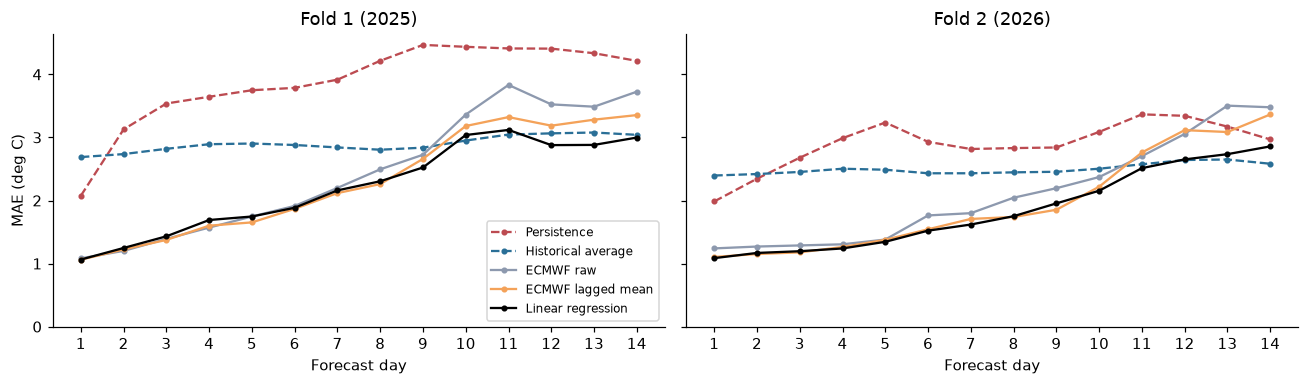

In [4]:
FOLDS = {"Fold 1 (2025)": ("2025-08-15", "2025-10-15"), "Fold 2 (2026)": ("2026-08-01", "2026-09-16")}
fold_errors = {name: evaluate(first, last, train_before=first) for name, (first, last) in FOLDS.items()}

overall = pd.concat({name: pd.DataFrame({"MAE": mae(e[METHODS]), "RMSE": rmse(e[METHODS])})
                     for name, e in fold_errors.items()}, axis=1)
lr_mae = overall.xs("MAE", axis=1, level=1).loc["Linear regression"]
gain = pd.DataFrame({name: {
    "vs Persistence": 100 * (1 - lr_mae[name] / overall.loc["Persistence", (name, "MAE")]),
    "vs Historical average": 100 * (1 - lr_mae[name] / overall.loc["Historical average", (name, "MAE")]),
} for name in FOLDS})
for name, e in fold_errors.items():
    print(f"{name}: {e.index.size:,} scored hours")
display(overall.round(2))
print("Linear regression: % lower MAE than the heuristics")
display(gain.round(0))

by_day = {name: e.groupby("lead_day")[METHODS].apply(mae).T for name, e in fold_errors.items()}
for name, table in by_day.items():
    print(f"MAE by forecast day - {name}")
    display(table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
styles = {"Persistence": ("#bc4b51", "--"), "Historical average": ("#2a6f97", "--"), "ECMWF raw": ("#8d99ae", "-"),
          "ECMWF lagged mean": ("#f4a259", "-"), "Linear regression": ("black", "-")}
for ax, (name, table) in zip(axes, by_day.items()):
    for method, (color, line) in styles.items():
        ax.plot(table.columns, table.loc[method], color=color, linestyle=line, marker="o", markersize=3, label=method)
    ax.set(title=name, xlabel="Forecast day")
    ax.set_xticks(range(1, 15))
axes[0].set(ylabel="MAE (deg C)", ylim=(0, None))
axes[0].legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "validation_mae_by_day")
plt.show()

## 4. Extra check: six 2026 windows

Six forecasts set up exactly like the real task (issued at 11pm, covering 14 days from 12am). The model is re-trained for each window on data before that window.

In [5]:
WINDOWS = {"Jun 1-14": "2026-06-01", "Jun 17-30": "2026-06-17", "Jul 1-14": "2026-07-01",
           "Jul 17-30": "2026-07-17", "Aug 1-14": "2026-08-01", "Aug 17-30": "2026-08-17"}
window_mae = {}
for name, first_day in WINDOWS.items():
    run_day = pd.Timestamp(first_day) - pd.Timedelta(days=1)  # issued at 11pm the evening before
    window_mae[name] = mae(evaluate(run_day, run_day, train_before=first_day)[METHODS])
window_mae = pd.DataFrame(window_mae)
window_mae["Average"] = window_mae.mean(axis=1)
display(window_mae.round(2))
print("Linear regression: % lower MAE than the heuristics")
display(pd.DataFrame({
    "vs Persistence": 100 * (1 - window_mae.loc["Linear regression"] / window_mae.loc["Persistence"]),
    "vs Historical average": 100 * (1 - window_mae.loc["Linear regression"] / window_mae.loc["Historical average"]),
}).T.round(0))

,Jun 1-14,Jun 17-30,Jul 1-14,Jul 17-30,Aug 1-14,Aug 17-30,Average
Persistence,6.38,2.97,2.88,4.31,2.86,2.81,3.70
Historical average,3.85,1.88,2.43,2.77,1.87,1.88,2.45
ECMWF raw,2.14,2.06,1.98,1.73,1.51,1.51,1.82
ECMWF lagged mean,2.31,1.85,2.05,2.02,1.50,1.51,1.87
Linear regression,2.85,1.34,1.94,1.78,1.68,1.50,1.85


Linear regression: % lower MAE than the heuristics


,Jun 1-14,Jun 17-30,Jul 1-14,Jul 17-30,Aug 1-14,Aug 17-30,Average
vs Persistence,55.0,55.0,33.0,59.0,41.0,47.0,50.0
vs Historical average,26.0,29.0,20.0,36.0,10.0,20.0,24.0


## 5. Final forecast: Sep 17–30, 2026

The final model is trained on every row with a target before 12am Sep 17. The forecast uses the ECMWF 12z run of Sep 16 (plus the two older runs) and observations up to 11:51pm Sep 16.

,passed
trained only on targets before 12am Sep 17,True
336 hours: 12am Sep 17 - 11pm Sep 30,True
a forecast for every hour,True


Saved reports/forecast_2026-09-17_to_2026-09-30_linear_regression.csv (trained on 303,211 rows)


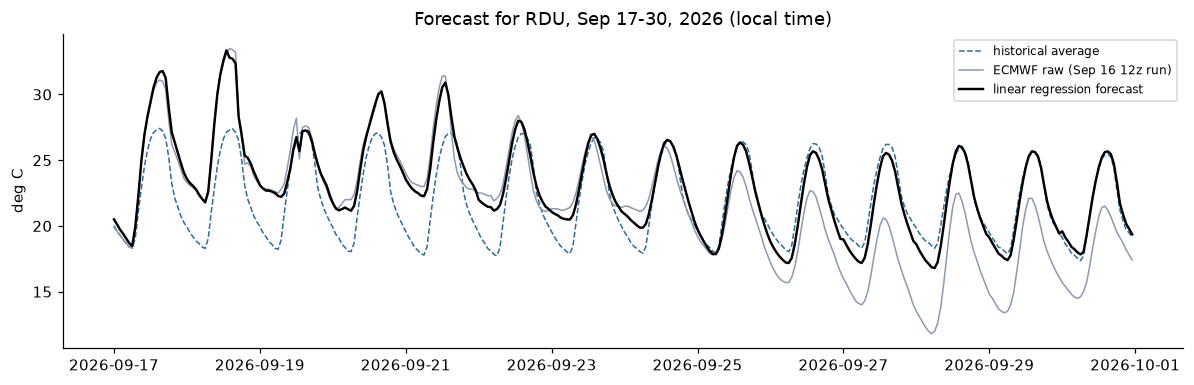

In [6]:
cutoff_utc = CUTOFF.tz_convert("UTC")
train_all = samples[(samples["target_utc"] < cutoff_utc) & samples["temperature"].notna()]
final = samples[samples["run_day"].eq(FINAL_RUN_DAY)].reset_index(drop=True)
final_models = fit_lr(train_all)
final["forecast"] = predict_lr(final_models, final)

checks = {
    "trained only on targets before 12am Sep 17": train_all["target_utc"].max() < cutoff_utc,
    "336 hours: 12am Sep 17 - 11pm Sep 30": len(final) == 336 and final["target_utc"].min() == cutoff_utc,
    "a forecast for every hour": final["forecast"].notna().all(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())

output = pd.DataFrame({
    "hour_local": final["target_local"],            # report at hh:51 is labelled hh
    "forecast_deg_c": final["forecast"].round(2),
    "historical_average_deg_c": final["hist_avg"].round(2),
    "ecmwf_raw_deg_c": final["ecmwf_12z"].round(2),
})
FORECAST_FILE.parent.mkdir(parents=True, exist_ok=True)
output.to_csv(FORECAST_FILE, index=False)
print(f"Saved {FORECAST_FILE.relative_to(PROJECT_ROOT)} (trained on {len(train_all):,} rows)")

fig, ax = plt.subplots(figsize=(11, 3.6))
when = pd.to_datetime(output["hour_local"])
ax.plot(when, output["historical_average_deg_c"], color="#2a6f97", linestyle="--", linewidth=1, label="historical average")
ax.plot(when, output["ecmwf_raw_deg_c"], color="#8d99ae", linewidth=1, label="ECMWF raw (Sep 16 12z run)")
ax.plot(when, output["forecast_deg_c"], color="black", linewidth=1.6, label="linear regression forecast")
ax.set(title="Forecast for RDU, Sep 17-30, 2026 (local time)", ylabel="deg C")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "final_forecast")
plt.show()

### 5.1 What the model learned

Adding the two ECMWF coefficients shows how much of ECMWF's forecast anomaly the model keeps on each forecast day; the rest falls back to the historical average. The second line shows how much of ECMWF's error over the last six observed hours is carried forward.

forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
weight on ECMWF (both ECMWF terms),0.94,1.00,0.98,0.95,0.92,0.87,0.83,0.81,0.75,0.66,0.57,0.48,0.38,0.24
weight on the recent ECMWF error,0.33,0.21,0.17,0.13,0.15,0.09,0.11,0.13,0.14,0.06,-0.06,-0.13,-0.03,0.03


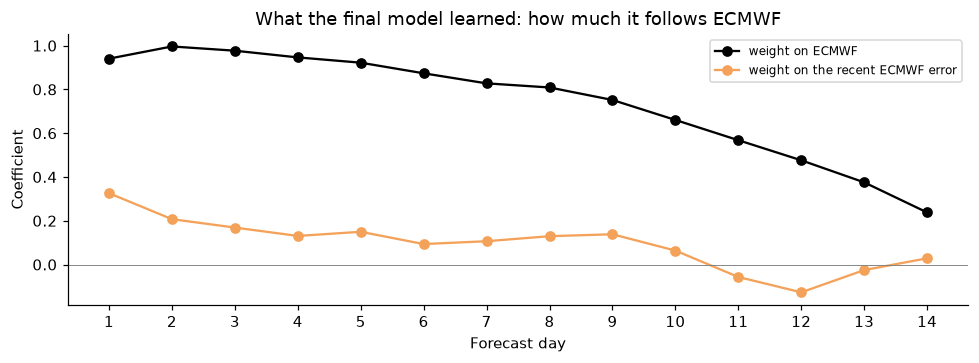

In [7]:
coefficients = pd.DataFrame({day: model.coef_ for day, model in final_models.items()}, index=FEATURES)
trust = pd.DataFrame({
    "weight on ECMWF (both ECMWF terms)": coefficients.loc["nwp_lagged_anomaly"] + coefficients.loc["nwp_anomaly"],
    "weight on the recent ECMWF error": coefficients.loc["nwp_recent_error"],
}).T
trust.columns.name = "forecast day"
display(trust.round(2))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(trust.columns, trust.iloc[0], marker="o", color="black", label="weight on ECMWF")
ax.plot(trust.columns, trust.iloc[1], marker="o", color="#f4a259", label="weight on the recent ECMWF error")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="What the final model learned: how much it follows ECMWF", xlabel="Forecast day", ylabel="Coefficient")
ax.set_xticks(range(1, 15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "lr_weight_on_ecmwf")
plt.show()